In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy
from dcalib import read_dca1000

In [3]:
# fileName="Sitting1Tx1Rx/static_sitting2.bin"
# fileName="Sitting1Tx1Rx/static_sitting2_Raw_0.bin"
# fileName="Sitting1Tx1Rx/static_sitting_no_breathing3.bin"
# fileName="Sitting1Tx1Rx/nothing.bin"
# fileName="11_30/11_30_highres_nomovement_nobreathing_59cm_1.bin"
fileName="12_8_2Tx4Rx/highres_nomovement_nobreathing_60cm_1.bin"
# fileName="11_30_1Tx4Rx/11_30_highres_nomovement_nobreathing_60cm_4_Raw_0.bin"
num_samples=640
dca_out=read_dca1000(fileName,num_adc_samples = 640, num_adc_bits = 16, num_rx=4)

In [4]:
def minmax_normalize(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    
    if max_val - min_val == 0:
        return np.zeros_like(arr)
        
    arr_std = (arr - min_val) / (max_val - min_val)
    
    return arr_std

def beamform_to_angle(data_in, target_angle_deg, start_freq=77.396e9):
    """
    Merges 4 RX channels into 1 by steering the beam to 'target_angle_deg'.
    
    Args:
        data_in: Shape (4, 10485760)
        target_angle_deg: The specific angle to focus on (e.g., 15.0)
        start_freq: 77.396e9 (Hz)
        
    Returns:
        data_out: Shape (1, 10485760)
    """
    
    # 1. Physics Constants
    c = 3e8
    wavelength = c / start_freq
    d = wavelength / 2  # Standard antenna spacing for AWR1843
    
    # 2. Create the Steering Vector
    # We have 4 antennas, indexed 0 to 3
    num_rx = data_in.shape[0]  # 4
    k = np.arange(num_rx)      # [0, 1, 2, 3]
    
    # Convert angle to radians
    theta_rad = np.deg2rad(target_angle_deg)
    
    # Calculate phase shift required for each antenna
    # Formula: 2 * pi * d * sin(theta) * k / lambda
    phase_shifts = (2 * np.pi * d * np.sin(theta_rad) * k) / wavelength
    
    # Create complex weights: e^(-j * phase)
    # Shape becomes (4,)
    weights = np.exp(-1j * phase_shifts)
    
    # 3. Apply Weights and Sum
    # Reshape weights to (4, 1) so we can multiply against (4, 10485760)
    weights = weights.reshape(-1, 1)
    
    # Multiply: This aligns the phases of the signal coming from 'target_angle'
    # Broadcasting: (4, 1) * (4, 10485760) -> (4, 10485760)
    weighted_data = data_in * weights
    
    # Sum across the RX dimension (Axis 0) to merge them
    # Shape becomes (10485760,)
    merged_data = np.sum(weighted_data, axis=0)
    
    # 4. Reshape to desired output (1, 10485760)
    data_out = merged_data.reshape(1, -1)
    
    return data_out

# --- Usage Example ---
# radar_cube shape: (128, 128, 4, 640)
target_angle = 10.5 # degrees

# New shape: (128, 128, 640)
# This new data effectively ignores energy coming from other angles
# single_channel_data = merge_channels_at_angle(radar_cube, target_angle)

In [5]:
print(dca_out.shape)
print(dca_out[0][1:10])

(4, 20971520)
[473.-176.j 427. +18.j 189. -43.j 221.-250.j 492.-288.j 588. -59.j
 512. +67.j 503. +16.j 614.+114.j]


In [322]:
# dca_out2=np.zeros((dca_out.shape[0],dca_out.shape[0]//2),dtype=complex)
# dca_out2=dca_out[:,0::2]
# dca_out=dca_out2
dca_out_merged= beamform_to_angle(dca_out, 5)

In [323]:
dca_out_merged.shape

(1, 10485760)

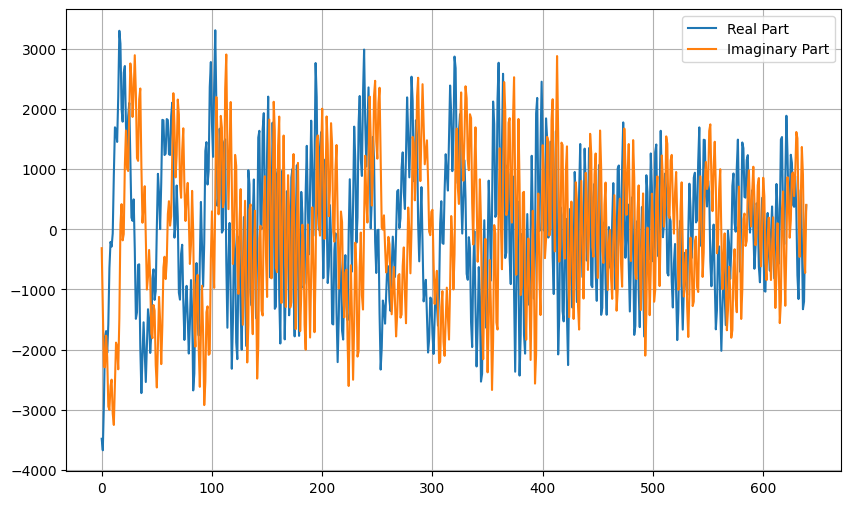

In [324]:
# Time domain
plt.figure(figsize=(10, 6))
chirp=1
# data=dca_out[0][chirp*num_samples:(chirp+1)*num_samples]
data=dca_out_merged[0][chirp*num_samples:(chirp+1)*num_samples]
# data=dca_out2[0][chirp*num_samples:(chirp+1)*num_samples:1]
real=data.real
complex_data=data.imag
plt.plot(real,'-',label='Real Part')
plt.plot(complex_data,'-',label='Imaginary Part')
plt.grid()
plt.legend()

In [325]:
print(dca_out)
print(dca_out.shape)

[[ -495. +731.j  -942. +586.j -1146. +139.j ...  -430. +191.j
   -189. -249.j   258. -155.j]
 [-1916. -163.j -1816. -891.j -1297.-1339.j ...    15. -194.j
    447.  -72.j   491. +365.j]
 [ -544.-1041.j  -257.-1176.j   242.-1079.j ...   125. -223.j
    339. +109.j   -14. +495.j]
 [  262. -615.j   238. -498.j   293. -356.j ...   404.  +88.j
    322. +254.j    94. +296.j]]
(4, 10485760)


In [326]:
3e8/(2*3.5199*1e9)

0.04261484701269922

In [327]:
sampling_frequency = 12000 * 1e3 # Hz (example)
S=65.998 * 1e12 #mhz/us
start_freq=77.396*1e9
ramp_end=60 #us
idle_time=100 #us
periodicity=40 #us
chirp_cycle_time=(idle_time + ramp_end + periodicity) * 1e-6
pulse_repetation_interval = 1/chirp_cycle_time
num_rx=1
num_chirps=1
samples_per_chirp=num_samples
chirps_per_frame=128
range_max=3e8*sampling_frequency/ (2*S)

frames_per_loop=128
chirp_loops=128

dca_out.shape[1]/samples_per_chirp/chirp_loops/frames_per_loop

1.0

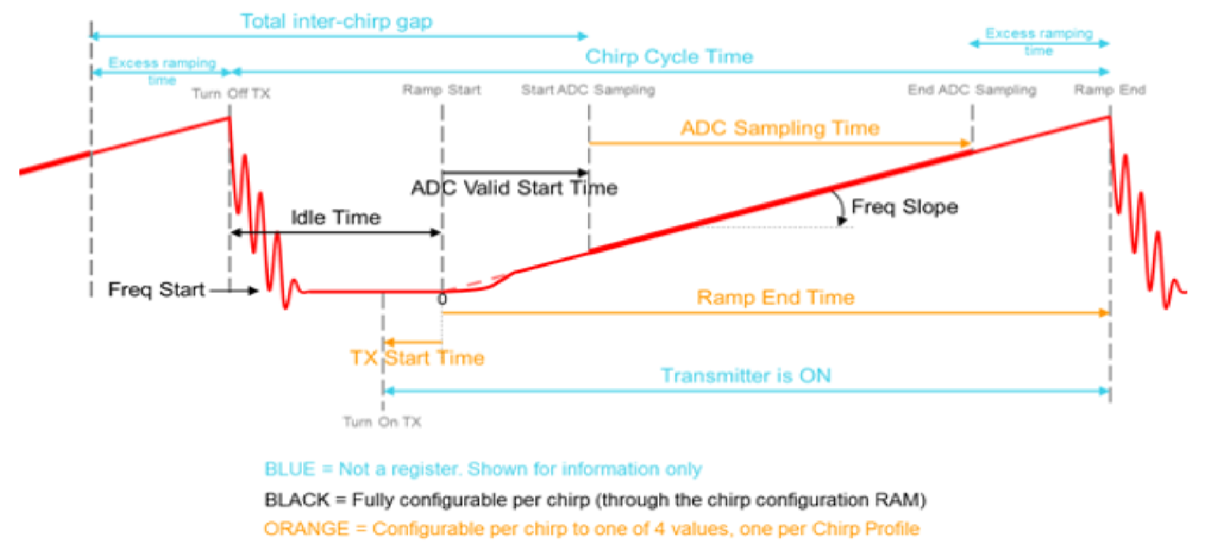

In [328]:
range_max

27.273553744052847

In [329]:
dca_out_merged[0][0]

np.complex128(-3661.9329484419272-124.12032035539983j)

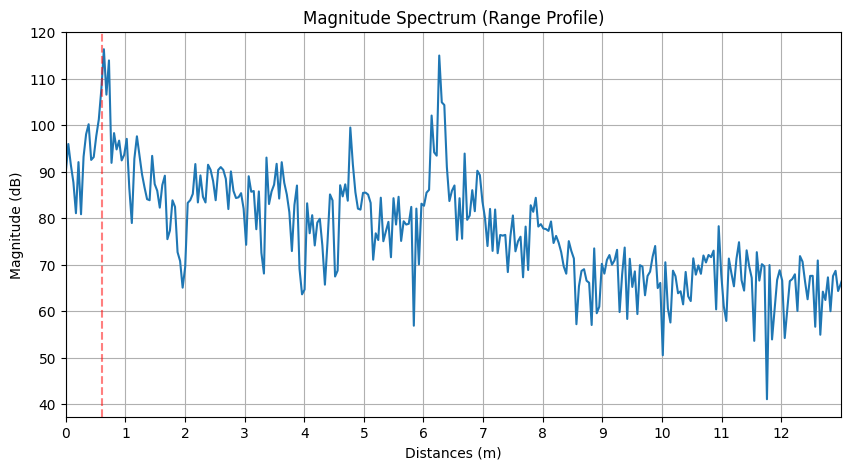

In [330]:
distance_idx=15
# distance_idx=126
def magnitude_dbfs(fft_data, adc_bits=16):
        """
        Convert complex FFT to magnitude in dBFS (decibels relative to full scale)
        
        Args:
            fft_data: Complex FFT output array
            adc_bits: ADC resolution in bits (default 12-bit for typical radar)
        
        Returns:
            magnitude_dbfs: Magnitude in dBFS scale
        """
        # Calculate full scale value based on ADC bits
        full_scale = 2**(adc_bits - 1)  # For signed ADC
        
        # Get magnitude of FFT
        magnitude = np.abs(fft_data)
        
        # Normalize by FFT length (important for proper scaling)
        magnitude_normalized = magnitude / len(fft_data)
        
        # Convert to dBFS: 20*log10(magnitude / full_scale)
        # Add small epsilon to avoid log(0)
        magnitude_dbfs = 20 * np.log10(magnitude_normalized / full_scale + 1e-10)
        
        return magnitude_dbfs

def magnitude_db(fft_data):
        """Convert complex FFT to magnitude in dB"""
        magnitude = np.abs(fft_data)
        magnitude_db = 20 * np.log10(magnitude + 1e-10)  # Add small value to avoid log(0)
        return magnitude_db

def rangeFFT(signal, plot=False):
    global range_max
    num_samples = len(signal)
    window = np.hanning(num_samples)
    signal_windowed = signal
    y=np.fft.fft(signal_windowed)
    # print(len(signal_windowed), len(y))
    fft_magnitude = magnitude_db(y,)
    # fft_magnitude = magnitude_dbfs(y,adc_bits=16)

    # frequencies = np.fft.fftshift(np.fft.fftfreq(num_samples, d=1/(sampling_frequency)))
    # distances=np.abs(frequencies)*3e8/2/S
    distances=np.arange(num_samples) * range_max / num_samples
    # print([distances[0],distances[-100]])
    if plot:
        # Plot the magnitude spectrum
        plt.figure(figsize=(10, 5))
        # plt.plot(frequencies[:num_samples//2], fft_magnitude[:num_samples//2]) # Plot only positive frequencies
        # plt.plot(distances[:num_samples//2], fft_magnitude[:num_samples//2]) # Plot only positive frequencies
        plt.plot(distances, fft_magnitude) # Plot only positive frequencies
        plt.title('Magnitude Spectrum (Range Profile)')
        # plt.xlabel('Frequency (Hz) / Range Bins')
        plt.xlabel('Distances (m)')
        plt.ylabel('Magnitude (dB)')
        plt.xticks(np.arange(0,range_max//2,1))
        plt.xlim([0,range_max//2])
        plt.grid(True)
        plt.axvline(x=0.6, color='r', linestyle='--', alpha=0.5)
        plt.show()
    return y, fft_magnitude, distances

# magAtXXcm=[]
# sigAtXXcm=[]
# distances_all=[]
# num_chirps=len(dca_out[0])//samples_per_chirp
# rangeFFTAcrossChirps=np.zeros([samples_per_chirp,len(dca_out[0])//samples_per_chirp],dtype=np.complex128)
# for chirp_no in range(len(dca_out[0])//samples_per_chirp):
#     if chirp_no==0:
#         fft_signal, fft_magnitude, distances=rangeFFT(dca_out[0][chirp_no*samples_per_chirp:(chirp_no+1)*samples_per_chirp], plot=True)
#     else:
#         fft_signal, fft_magnitude, distances=rangeFFT(dca_out[0][chirp_no*samples_per_chirp:(chirp_no+1)*samples_per_chirp], plot=False)
#     rangeFFTAcrossChirps[:,chirp_no]=fft_signal
#     sigAtXXcm.append(fft_signal[distance_idx]) 
#     magAtXXcm.append(fft_magnitude[distance_idx]) 
#     distances_all.append(distances[distance_idx])
# sigAt58cm=np.array(sigAtXXcm)
# magAt58cm=np.array(magAtXXcm)



magAtXXcm=[]
sigAtXXcm=[]
distances_all=[]
num_chirps=len(dca_out_merged[0])//samples_per_chirp
rangeFFTAcrossChirps=np.zeros([samples_per_chirp,len(dca_out_merged[0])//samples_per_chirp],dtype=np.complex128)
for chirp_no in range(len(dca_out_merged[0])//samples_per_chirp):
    if chirp_no==0:
        fft_signal, fft_magnitude, distances=rangeFFT(dca_out_merged[0][chirp_no*samples_per_chirp:(chirp_no+1)*samples_per_chirp], plot=True)
    else:
        fft_signal, fft_magnitude, distances=rangeFFT(dca_out_merged[0][chirp_no*samples_per_chirp:(chirp_no+1)*samples_per_chirp], plot=False)
    rangeFFTAcrossChirps[:,chirp_no]=fft_signal
    sigAtXXcm.append(fft_signal[distance_idx]) 
    magAtXXcm.append(fft_magnitude[distance_idx]) 
    distances_all.append(distances[distance_idx])
sigAt58cm=np.array(sigAtXXcm)
magAt58cm=np.array(magAtXXcm)

In [331]:
distances[distance_idx]

np.float64(0.6392239158762386)

In [332]:
rangeFFTAcrossChirps.shape

(640, 16384)

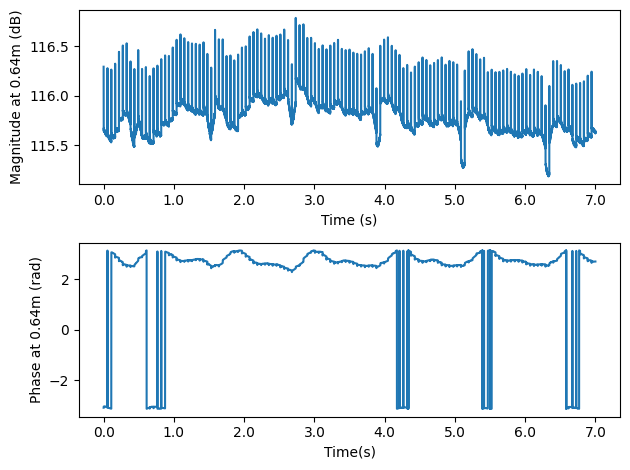

In [333]:
# plt.plot(np.arange(rangeFFTAcrossChirps.shape[1]),magnitude_db(rangeFFTAcrossChirps[3,:]))
# plt.plot(np.arange(len(magAtXXcm[:])),magAtXXcm[:])

# --- Create x-ticks for 0–7 seconds ---
total_time = 7  # seconds
num_ticks = 8   # ticks at 0,1,2,...,7 sec

tick_positions = np.linspace(0, rangeFFTAcrossChirps.shape[1]-1, num_ticks)
tick_labels = np.linspace(0, total_time, num_ticks)

plt.subplot(2,1,1)
plt.plot(np.arange(len(magAtXXcm[:])),magnitude_db(rangeFFTAcrossChirps[distance_idx,:]))
plt.xlabel('Time (s)')
plt.ylabel(f'Magnitude at {np.round(distances[distance_idx],2)}m (dB)')
plt.xticks(tick_positions, tick_labels)

plt.subplot(2,1,2)
plt.plot(np.arange(len(magAtXXcm[:])),np.angle(rangeFFTAcrossChirps[distance_idx,:]))
plt.xlabel('Time(s)')
plt.ylabel(f'Phase at {np.round(distances[distance_idx],2)}m (rad)')
plt.tight_layout()
plt.xticks(tick_positions, tick_labels)
plt.show()

In [334]:
len(distances)

640

In [335]:
rangeFFTAcrossChirps.shape

(640, 16384)

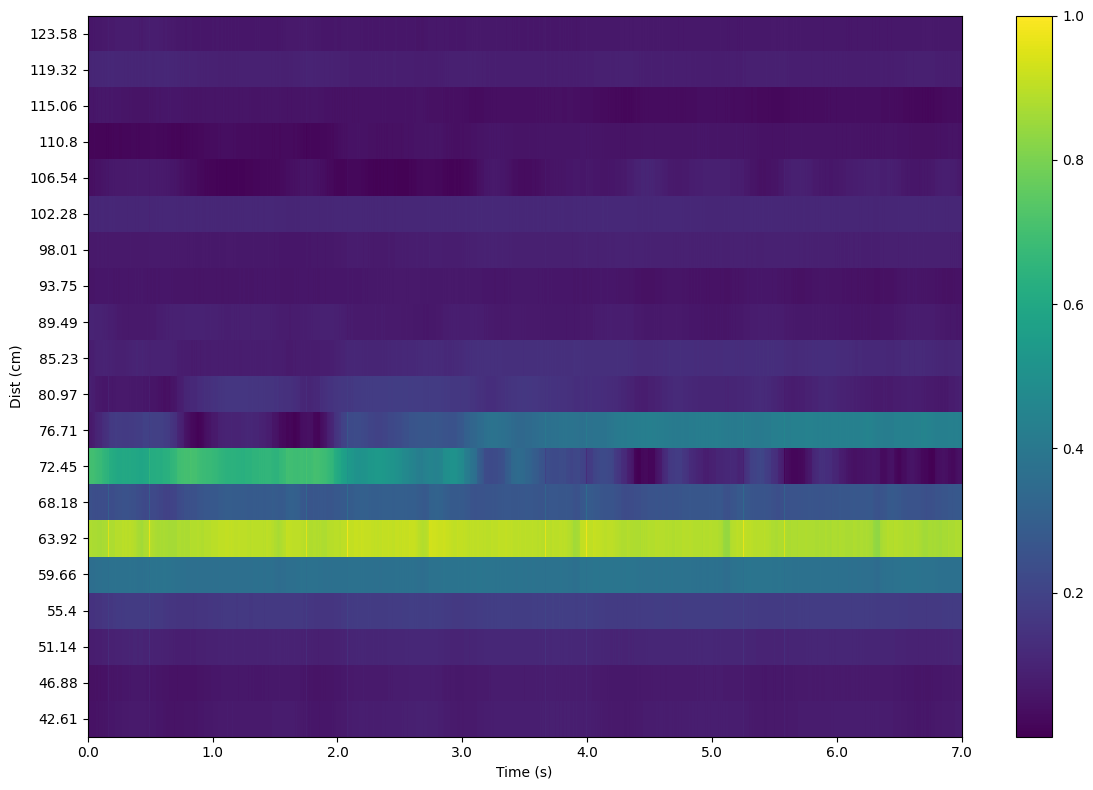

In [336]:
# Example 2D array (replace with your own)

distances=np.array(distances)
plt.figure(figsize=(12, 8))
idxes=np.arange(10,30)
x_idxes=np.arange(0,rangeFFTAcrossChirps.shape[1])
rangeFFTAcrossChirps_abs=np.abs(rangeFFTAcrossChirps)
rangeFFTAcrossChirps_norm=(rangeFFTAcrossChirps_abs - np.min(rangeFFTAcrossChirps_abs))/(np.max(rangeFFTAcrossChirps_abs)-np.min(rangeFFTAcrossChirps_abs))
plt.imshow((rangeFFTAcrossChirps_norm[idxes[:, None], x_idxes]), aspect='auto', cmap='viridis', origin='lower',  interpolation='nearest')
# plt.imshow(magnitude_db(rangeFFTAcrossChirps[idxes,:]), aspect='auto', cmap='viridis', origin='lower')

yticks = np.arange(len(rangeFFTAcrossChirps[idxes]))        # positions 0..19
ytick_labels = np.round(distances[idxes]*100,2)                  # your labels
plt.yticks(yticks, ytick_labels)



# --- Create x-ticks for 0–7 seconds ---
total_time = 7  # seconds
num_ticks = 8   # ticks at 0,1,2,...,7 sec

tick_positions = np.linspace(0, rangeFFTAcrossChirps[:,x_idxes].shape[1]-1, num_ticks)
tick_labels = np.linspace(0, total_time, num_ticks)

plt.xticks(tick_positions, tick_labels)
plt.xlabel("Time (s)")
plt.ylabel("Dist (cm)")
plt.colorbar()
plt.tight_layout()
plt.show()


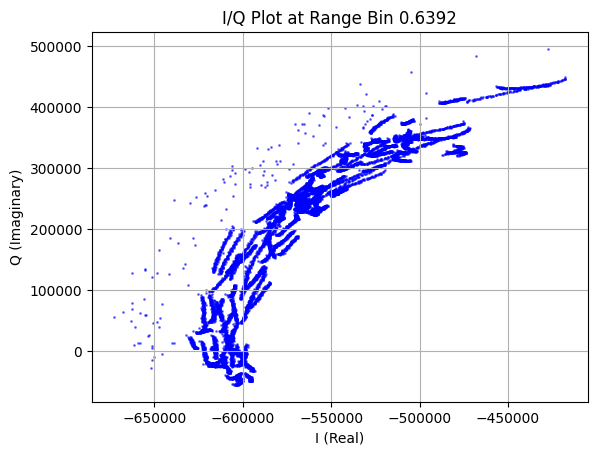

In [337]:
# 1. Extract the complex signal for the specific range bin across all chirps
# This vector represents how the target behaves over 'slow time'
complex_signal = rangeFFTAcrossChirps[distance_idx, :]

# 2. Extract I (Real) and Q (Imaginary) components
I_data = np.real(complex_signal)
Q_data = np.imag(complex_signal)


# 3. Plot
# plt.figure(figsize=(6, 6))  # Square figure is best for IQ plots
plt.scatter(I_data, Q_data, s=1, c='blue', alpha=0.5) # s=1 for small points like your image

# Optional: Make it look exactly like your reference
# plt.xlim([-5e4, 5e4]) # Adjust scale to match your data
# plt.ylim([-5e4, 5e4])

plt.title(f'I/Q Plot at Range Bin {np.round(distances[distance_idx],4)}')
plt.xlabel('I (Real)')
plt.ylabel('Q (Imaginary)')
plt.grid(True)
# plt.axis('equal') # Important: Keeps circles looking like circles, not ovals
plt.show()

# Doppler FFT
## The following code assumes that all chirps belong to just one frame. 

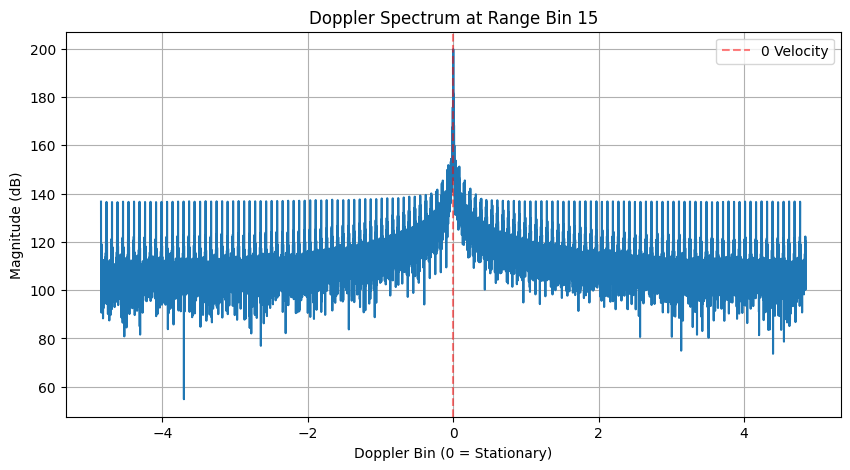

In [338]:

dop_all_fft=np.fft.fft(rangeFFTAcrossChirps,axis=1) # axis = 1 to perform fft across 640 rows.
dop_fft=dop_all_fft[distance_idx,:]


# 1. Shift the zero-frequency component to the center of the spectrum
dop_fft_shifted = np.fft.fftshift(dop_fft)

# 2. Get magnitude in dB
dop_mag_db = 20 * np.log10(np.abs(dop_fft_shifted) + 1e-10)

# 3. Create an axis for the plot (Indices centered around 0)
num_chirps = dop_fft.shape[0]
velocity_axis = np.arange(-num_chirps/2, num_chirps/2)
velocity_axis = velocity_axis * 3e8/(start_freq * num_chirps * chirp_cycle_time * 2)
# 4. Plot
plt.figure(figsize=(10, 5))
plt.plot(velocity_axis, dop_mag_db)
plt.title(f'Doppler Spectrum at Range Bin {distance_idx}')
plt.xlabel('Doppler Bin (0 = Stationary)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='0 Velocity')
plt.legend()
plt.show()

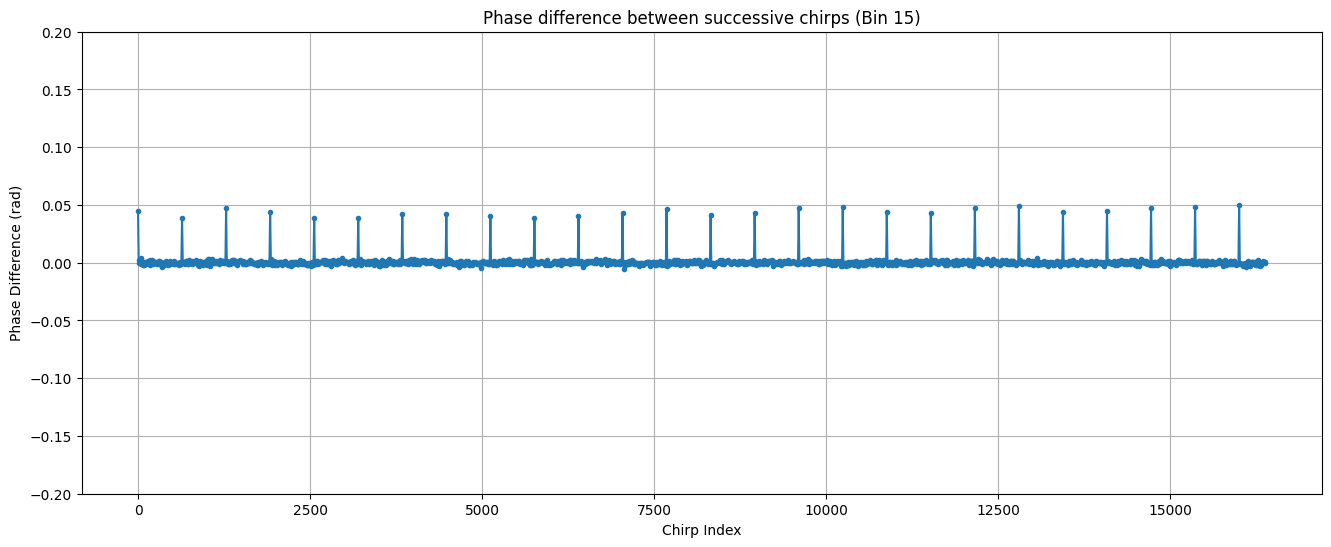

In [339]:
# 1. Get the Time-Domain signal (Slow Time) for the specific range bin
# Do NOT use the output of the FFT; use the input to the FFT.
slow_time_signal = rangeFFTAcrossChirps[distance_idx, :] 

# 2. Calculate phase difference between successive CHIRPS
# (Current Chirp * Conjugate of Previous Chirp)
phi_diff = np.angle(slow_time_signal[1:] * np.conj(slow_time_signal[:-1])) # radians

# Optional: Convert phase difference -> velocity (m/s)
# velocity = (phi_diff * wavelength) / (4 * np.pi * chirp_duration)

# Plotting
plt.figure(figsize=(16, 6))
skip = 10 # Plot every point to see the full trend

plt.plot(
    np.arange(len(phi_diff))[::skip],
    phi_diff[::skip],
    '.-'
)
plt.ylim([-0.2, 0.2])

plt.xlabel("Chirp Index")
plt.ylabel("Phase Difference (rad)")
plt.title(f"Phase difference between successive chirps (Bin {distance_idx})")
plt.grid(True)
plt.show()

# If you need this for ALL range bins:
phi_diff_all = np.angle(
    rangeFFTAcrossChirps[:, 1:] * np.conj(rangeFFTAcrossChirps[:, :-1])
)

# Beamforming

Radar Cube Shape: (128, 128, 4, 640)


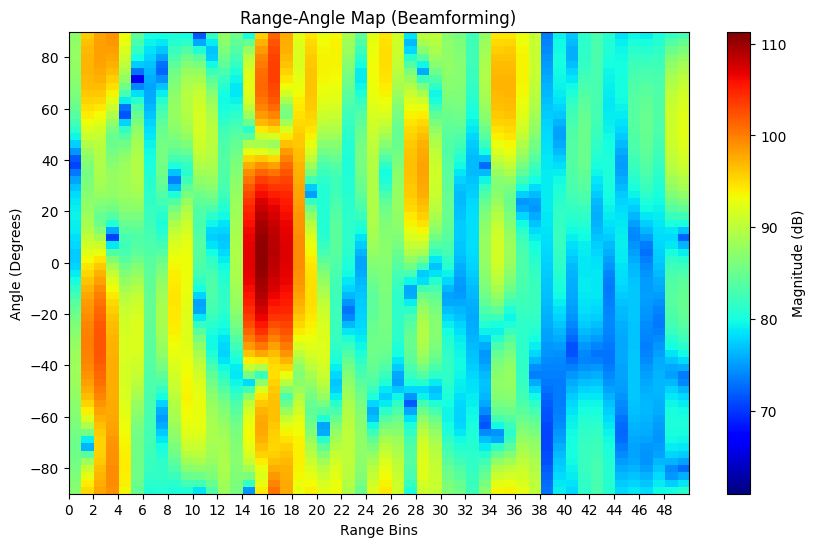

In [340]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configuration Parameters ---
num_frames = 128
num_chirps = 128
num_rx=4

# --- 2. Reshape to Radar Cube ---
# Goal: (Frames, Chirps, RX, Samples)
# Note: Depending on how the DCA1000 captured data, the RX dimension 
# might need to be transposed. Standard TI format usually requires:
# Transpose to -> (Frames, Chirps, RX, Samples)

# Reshape raw buffer to (RX, Frames, Chirps, Samples)
radar_cube = dca_out.reshape(num_rx, num_frames, num_chirps, num_samples)

# Move axes to standard (Frames, Chirps, RX, Samples) order
radar_cube = np.transpose(radar_cube, (1, 2, 0, 3))

print(f"Radar Cube Shape: {radar_cube.shape}") 
# Expected: (128, 128, 4, 640)

# --- 3. Processing Loop (Per Frame) ---
# We will process the first frame as an example
frame_idx = 0
frame_data = radar_cube[frame_idx] # Shape: (Chirps, RX, Samples)

# A. Range FFT (Axis 2: Samples)
# Apply Windowing to reduce leakage (Hanning)
window_range = np.hanning(num_samples)
range_fft = np.fft.fft(frame_data * window_range, axis=2)

# B. Doppler FFT (Axis 0: Chirps) - Optional for Range-Angle, but good for filtering
window_doppler = np.hanning(num_chirps).reshape(-1, 1, 1)
doppler_fft = np.fft.fft(range_fft * window_doppler, axis=0)

# Shift zero frequency to center for Doppler
doppler_fft = np.fft.fftshift(doppler_fft, axes=0)

# --- 4. Digital Beamforming (Angle FFT) ---
# We perform FFT across the RX antennas (Axis 1)
# 4 RX antennas = very low angular resolution, so we usually zero-pad 
# to interpolate and make the plot smoother.

n_angle_fft_bins = 64 # Zero padding length (e.g., 64 or 128)

# Select the zero-Doppler bin (static objects) or max-Doppler bin 
# For this visualization, let's sum across all Doppler bins (non-coherent integration)
# Or just take the 0-Doppler slice to see static objects.
range_azimuth_data = doppler_fft[:, :, :] # Keep (Doppler, RX, Range)

# Perform FFT along RX dimension (Axis 1)
# This converts spatial domain (antennas) to angle domain
angle_fft = np.fft.fft(range_azimuth_data, n=n_angle_fft_bins, axis=1)
angle_fft = np.fft.fftshift(angle_fft, axes=1) # Shift 0 angle to center

# --- 5. Visualization (Range-Angle Map) ---
# We generally visualize Range vs Angle. 
# We need to collapse the Doppler dimension (e.g., take the max or mean)
# Shape: (Doppler, Angle, Range) -> (Angle, Range)
range_angle_map = np.mean(np.abs(angle_fft), axis=0)

# Convert to Log scale (dB)
range_angle_map_db = 20 * np.log10(range_angle_map + 1e-9)

# Plotting
plt.figure(figsize=(10, 6))
# Extent defines the axes: [Range Start, Range Max, Angle Start, Angle End]
# Angle corresponds to -90 to +90 degrees usually
plt.imshow(range_angle_map_db, aspect='auto', origin='lower', cmap='jet',
           extent=[0, num_samples, -90, 90])
plt.xlim([0,50])
plt.xticks(np.arange(0,50,2))
plt.title('Range-Angle Map (Beamforming)')
plt.xlabel('Range Bins')
plt.ylabel('Angle (Degrees)')
plt.colorbar(label='Magnitude (dB)')
plt.grid(False)
plt.show()

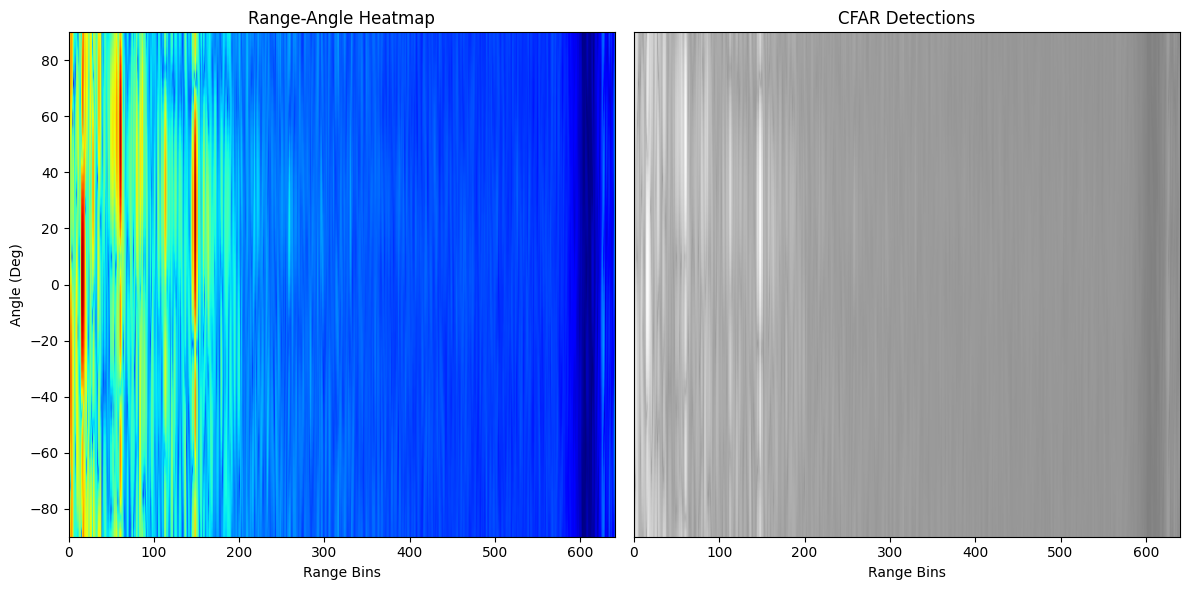

Detected 19 points.
Target at Range Bin: 147, Angle Bin: 32
Target at Range Bin: 147, Angle Bin: 33
Target at Range Bin: 147, Angle Bin: 34
Target at Range Bin: 147, Angle Bin: 35
Target at Range Bin: 147, Angle Bin: 36
Target at Range Bin: 147, Angle Bin: 37
Target at Range Bin: 147, Angle Bin: 38
Target at Range Bin: 147, Angle Bin: 39
Target at Range Bin: 147, Angle Bin: 40
Target at Range Bin: 147, Angle Bin: 41
Target at Range Bin: 147, Angle Bin: 42
Target at Range Bin: 147, Angle Bin: 43
Target at Range Bin: 147, Angle Bin: 44
Target at Range Bin: 147, Angle Bin: 45
Target at Range Bin: 147, Angle Bin: 46
Target at Range Bin: 147, Angle Bin: 47
Target at Range Bin: 147, Angle Bin: 48
Target at Range Bin: 147, Angle Bin: 49
Target at Range Bin: 147, Angle Bin: 50


In [341]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# --- [Previous steps 1-4 from the beamforming code remain the same] ---
# Assuming 'angle_fft' is available from the previous step.
# We re-calculate the linear magnitude map for CFAR (CFAR works best on linear power/mag)
range_angle_map_linear = np.mean(np.abs(angle_fft), axis=0) # Shape: (Angle, Range)

# --- 5. 2D CA-CFAR Implementation ---

def apply_cfar_2d(input_map, num_train_range, num_train_angle, num_guard_range, num_guard_angle, pfa=1e-5):
    """
    Applies 2D Cell Averaging CFAR using convolution for speed.
    """
    # 1. Create the Kernel (Window)
    # The kernel size includes CUT + Guards + Training cells on both sides
    win_range = 1 + (2 * num_guard_range) + (2 * num_train_range)
    win_angle = 1 + (2 * num_guard_angle) + (2 * num_train_angle)
    
    kernel = np.ones((win_angle, win_range))
    
    # 2. Normalize the kernel to calculate the Average (Mean)
    # Set the Guard region (center) to 0 so we don't include it in the noise calculation
    # Guard region start/end indices
    guard_r_start = num_train_range
    guard_r_end = num_train_range + (2 * num_guard_range) + 1
    guard_a_start = num_train_angle
    guard_a_end = num_train_angle + (2 * num_guard_angle) + 1
    
    kernel[guard_a_start:guard_a_end, guard_r_start:guard_r_end] = 0
    
    # Count how many training cells we actually have (to normalize the sum later)
    num_train_cells = np.sum(kernel)
    
    # Normalize kernel so convolution results in the Mean of training cells
    kernel = kernel / num_train_cells

    # 3. Convolve to get the Noise Floor Map
    # mode='mirror' handles the edges of the map
    noise_floor_map = convolve(input_map, kernel, mode='mirror')

    # 4. Calculate Threshold
    # For linear detector, Threshold = Noise_Level * (alpha)
    # Alpha can be derived from Pfa (Probability of False Alarm)
    # alpha = num_train_cells * (pfa**(-1/num_train_cells) - 1) 
    # Or simplified roughly as a linear multiplier for testing:
    threshold_offset = 15 # e.g., 15 linear units or dB equivalent scaling
    
    # Usually easier to work in Log domain for threshold offset:
    # If input is linear, we compute threshold factor:
    alpha = num_train_cells * (pfa**(-1.0/num_train_cells) - 1)
    
    # Apply Threshold
    threshold_map = noise_floor_map * (1 + alpha)
    
    # 5. Generate Detection Map (Boolean)
    detections = (input_map > threshold_map)
    
    return detections, threshold_map

# --- 6. Run CFAR ---
# Parameters need tuning based on your specific environment
# Range cells are usually dense (640 bins), Angle cells are sparse (64 bins)
detections, _ = apply_cfar_2d(range_angle_map_linear, 
                              num_train_range=12, num_train_angle=4,
                              num_guard_range=4, num_guard_angle=2, 
                              pfa=1e-4)

# --- 7. Visualization ---

# Convert background map to dB for plotting
range_angle_map_db = 20 * np.log10(range_angle_map_linear + 1e-9)

plt.figure(figsize=(12, 6))

# Plot 1: The Heatmap
plt.subplot(1, 2, 1)
plt.imshow(range_angle_map_db, aspect='auto', origin='lower', cmap='jet',
           extent=[0, num_samples, -90, 90])
plt.title('Range-Angle Heatmap')
plt.xlabel('Range Bins')
plt.ylabel('Angle (Deg)')

# Plot 2: The Detections (Overlay)
# We mask the 0s (False) so they don't show up on the plot
detection_mask = np.ma.masked_where(detections == 0, detections)

plt.subplot(1, 2, 2)
# Re-plot heatmap faded
plt.imshow(range_angle_map_db, aspect='auto', origin='lower', cmap='gray', alpha=0.5,
           extent=[0, num_samples, -90, 90])
# Overlay detections in Red
plt.imshow(detection_mask, aspect='auto', origin='lower', cmap='autumn', interpolation='none',
           extent=[0, num_samples, -90, 90])
plt.title('CFAR Detections')
plt.xlabel('Range Bins')
plt.yticks([]) # Hide Y axis labels for cleaner look

plt.tight_layout()
plt.show()

# Print detected coordinates
angle_idxs, range_idxs = np.where(detections == 1)
print(f"Detected {len(range_idxs)} points.")
for r, a in zip(range_idxs, angle_idxs):
    # Convert indices to actual units if needed
    print(f"Target at Range Bin: {r}, Angle Bin: {a}")